# Stock Price Prediction — S&P 500 (`^GSPC`)

**Student ID:** F74148557 | **Homework:** HW_1

| Parameter | Value |
|---|---|
| **Data Source** | `yfinance` — S&P 500 (`^GSPC`) |
| **Period** | 2021-01-01 to 2025-12-31 |
| **Models** | RandomForest vs XGBoost |
| **Evaluation** | MSE (Mean Squared Error) |
| **Train Set** | 2021-01-01 to 2024-12-31 |
| **Test Set** | 2025-01-01 to 2025-12-31 |
| **Tuning** | Bayesian Optimization (scikit-optimize & Optuna) |
| **Target** | Next-day Close Price |
| **Scaling** | Not applied (tree-based models are scale-invariant) |

In [1]:
!pip install yfinance scikit-optimize xgboost optuna seaborn -q

In [2]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# Bayesian Optimization — scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Bayesian Optimization — Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
sns.set_theme(style='darkgrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Data Acquisition
Download S&P 500 daily OHLCV data from Yahoo Finance via `yfinance`.

In [3]:
ticker = '^GSPC'
df_raw = yf.download(ticker, start='2021-01-01', end='2025-12-31', auto_adjust=True, progress=False)

# Flatten MultiIndex columns if present
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df_raw = df_raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df_raw.dropna(inplace=True)

print(f'Trading days downloaded : {len(df_raw)}')
print(f'Date range              : {df_raw.index[0].date()} to {df_raw.index[-1].date()}')
df_raw.tail()

Trading days downloaded : 1254
Date range              : 2021-01-04 to 2025-12-30


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-12-23,6872.410156,6910.879883,6868.810059,6909.790039,3820560000
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000
2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,2586550000
2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,3541750000
2025-12-30,6900.439941,6913.250000,6893.470215,6896.240234,3309930000


## 2. Feature Engineering

All features are computed using **only past data** (shifted by at least 1 day) to prevent **data leakage**.
The prediction target is the **next-day Close price** (`Close.shift(-1)`).

### Feature Groups

#### Lag & Return Features
Directly capture recent price history and momentum.
- `Close_lag_1..5` — Close prices from 1 to 5 days ago
- `Return_lag_1..5` — Log-returns `log(P_t / P_{t-1})` shifted 1..5 days. Log-returns are stationary (unlike raw prices), making trend patterns easier to detect.
- `Volume_lag_1` — Yesterday's trading volume
- `High_Low_range` — Daily intraday range (High - Low), a simple volatility proxy

#### Rolling Statistics
Capture trend direction and recent volatility regime.
- `MA_5`, `MA_10`, `MA_20` — Rolling mean of Close (short, medium, long-term trend)
- `Std_5`, `Std_10` — Rolling standard deviation (volatility)

#### RSI — Relative Strength Index (14-day)
Momentum oscillator ranging 0–100. Measures the speed and magnitude of recent price changes.
- RSI > 70: overbought signal (potential pullback)
- RSI < 30: oversold signal (potential recovery)
- Formula: `RSI = 100 - 100 / (1 + avg_gain / avg_loss)` over 14 days

#### MACD — Moving Average Convergence Divergence
Trend-following momentum indicator combining two EMAs.
- `MACD` = EMA(12) - EMA(26): positive = short-term bullish momentum
- `MACD_signal` = 9-day EMA of MACD: acts as trigger line
- `MACD_hist` = MACD - Signal: histogram showing momentum strength; crossover signals potential trend change

#### Bollinger Bands (20-day, ±2 std)
Volatility bands built around a 20-day SMA ± 2 standard deviations.
- `BB_bandwidth` = (Upper - Lower) / Middle — how wide the bands are (high = high volatility)
- `BB_pct_b` = (Price - Lower) / (Upper - Lower) — price position within bands: >1 overbought, <0 oversold

#### ATR — Average True Range (14-day)
Absolute volatility measure, regardless of direction.
- True Range = max(High-Low, |High-PrevClose|, |Low-PrevClose|)
- ATR = 14-day rolling mean of True Range
- Useful for assessing current volatility regime

#### OBV — On-Balance Volume
Tracks cumulative volume flow relative to price direction.
- Price up day: add volume; price down day: subtract volume
- Rising OBV with rising price = strong institutional accumulation
- OBV divergence from price can signal trend reversal

In [4]:
def create_features(df):
    data = df.copy()

    # --- Lag & Return Features ---
    for lag in range(1, 6):
        data[f'Close_lag_{lag}'] = data['Close'].shift(lag)
        data[f'Return_lag_{lag}'] = np.log(data['Close'] / data['Close'].shift(1)).shift(lag)
    data['Volume_lag_1'] = data['Volume'].shift(1)
    data['High_Low_range'] = (data['High'] - data['Low']).shift(1)

    # --- Rolling Statistics ---
    for w in [5, 10, 20]:
        data[f'MA_{w}'] = data['Close'].shift(1).rolling(w).mean()
    for w in [5, 10]:
        data[f'Std_{w}'] = data['Close'].shift(1).rolling(w).std()

    # --- RSI (14-day) ---
    delta = data['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    data['RSI_14'] = (100 - (100 / (1 + rs))).shift(1)

    # --- MACD ---
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    data['MACD'] = macd_line.shift(1)
    data['MACD_signal'] = signal_line.shift(1)
    data['MACD_hist'] = (macd_line - signal_line).shift(1)

    # --- Bollinger Bands (20-day, 2-sigma) ---
    ma20 = data['Close'].shift(1).rolling(20).mean()
    std20 = data['Close'].shift(1).rolling(20).std()
    bb_upper = ma20 + 2 * std20
    bb_lower = ma20 - 2 * std20
    data['BB_bandwidth'] = (bb_upper - bb_lower) / (ma20 + 1e-10)
    data['BB_pct_b'] = (data['Close'].shift(1) - bb_lower) / (bb_upper - bb_lower + 1e-10)

    # --- ATR (14-day) ---
    tr = pd.concat([
        data['High'] - data['Low'],
        (data['High'] - data['Close'].shift(1)).abs(),
        (data['Low']  - data['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    data['ATR_14'] = tr.rolling(14).mean().shift(1)

    # --- OBV ---
    direction = np.sign(data['Close'].diff()).fillna(0)
    data['OBV'] = (data['Volume'] * direction).cumsum().shift(1)

    # --- Target: next-day Close ---
    data['Target'] = data['Close'].shift(-1)

    # Drop raw OHLCV to prevent data leakage
    data.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)
    data.dropna(inplace=True)
    return data


df_feat = create_features(df_raw)
feature_cols = [c for c in df_feat.columns if c != 'Target']

print(f'Feature matrix : {df_feat.shape[0]} rows x {len(feature_cols)} features')
print(f'Features       : {feature_cols}')
df_feat.tail(3)

Feature matrix : 1233 rows x 25 features
Features       : ['Close_lag_1', 'Return_lag_1', 'Close_lag_2', 'Return_lag_2', 'Close_lag_3', 'Return_lag_3', 'Close_lag_4', 'Return_lag_4', 'Close_lag_5', 'Return_lag_5', 'Volume_lag_1', 'High_Low_range', 'MA_5', 'MA_10', 'MA_20', 'Std_5', 'Std_10', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_bandwidth', 'BB_pct_b', 'ATR_14', 'OBV']


Price,Close_lag_1,Return_lag_1,Close_lag_2,Return_lag_2,Close_lag_3,Return_lag_3,Close_lag_4,Return_lag_4,Close_lag_5,Return_lag_5,...,Std_10,RSI_14,MACD,MACD_signal,MACD_hist,BB_bandwidth,BB_pct_b,ATR_14,OBV,Target
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,6909.790039,0.004540,6878.490234,0.006416,6834.500000,0.008779,6774.759766,0.007903,6721.430176,-0.011660,...,60.226739,56.270471,24.354503,21.945944,2.408559,0.027111,0.907797,61.628418,3.531034e+11,6929.939941
2025-12-26,6932.049805,0.003216,6909.790039,0.004540,6878.490234,0.006416,6834.500000,0.008779,6774.759766,0.007903,...,65.979621,57.586286,30.370597,23.630875,6.739722,0.028221,0.963524,61.132673,3.549016e+11,6905.740234
2025-12-29,6929.939941,-0.000304,6932.049805,0.003216,6909.790039,0.004540,6878.490234,0.006416,6834.500000,0.008779,...,69.511174,56.167655,34.569648,25.818629,8.751019,0.030063,0.896013,60.097691,3.523151e+11,6896.240234


## 3. Train / Test Split (Date-Based)

Split is done **strictly by date** — no shuffling — to preserve temporal order and simulate real-world deployment.

In [5]:
train_df = df_feat[df_feat.index < '2025-01-01']
test_df  = df_feat[df_feat.index >= '2025-01-01']

X_train, y_train = train_df[feature_cols], train_df['Target']
X_test,  y_test  = test_df[feature_cols],  test_df['Target']

print(f'Train: {X_train.index[0].date()} to {X_train.index[-1].date()}  ({len(X_train)} trading days)')
print(f'Test : {X_test.index[0].date()} to {X_test.index[-1].date()}  ({len(X_test)} trading days)')
print(f'Number of features: {len(feature_cols)}')

Train: 2021-02-02 to 2024-12-31  (985 trading days)
Test : 2025-01-02 to 2025-12-29  (248 trading days)
Number of features: 25


## 4. Bayesian Optimization — scikit-optimize vs Optuna

Both libraries search hyperparameter spaces more efficiently than grid or random search by building a probabilistic model of the objective function.

| Feature | scikit-optimize (`BayesSearchCV`) | Optuna (TPE) |
|---|---|---|
| **Surrogate model** | Gaussian Process (GP) | Tree-structured Parzen Estimator (TPE) |
| **Acquisition fn** | Expected Improvement | EI via P(good) / P(bad) |
| **Speed** | Slower — GP fitting is O(n^3) | Faster — TPE scales linearly with trials |
| **sklearn integration** | Native `BayesSearchCV` (drop-in for `GridSearchCV`) | Custom objective function required |
| **Early pruning** | Not supported | Supported (`MedianPruner`, `HyperbandPruner`) |
| **Parallelism** | Limited | Excellent (async, distributed) |
| **Visualization** | Basic | Rich (`optuna-dashboard`) |
| **Best for** | Small spaces, sklearn users | Many trials, large search spaces |

**scikit-optimize** fits a GP over all previous trials and picks the next point that maximizes Expected Improvement. Theoretically sound but slows for >50 iterations.

**Optuna (TPE)** splits past trials into 'good' (top quantile) and 'bad', then models each with kernel density estimation. It selects the next point by maximizing the ratio — much faster and supports pruning unpromising trials early.

We implement **both** below and compare results. Cross-validation uses `TimeSeriesSplit(n_splits=5)` to preserve temporal order within the training set.

In [6]:
# ---------------------------------------------------------------
# Bayesian Optimization with scikit-optimize (BayesSearchCV)
# ---------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

print('scikit-optimize: RandomForest ...')
rf_space = {
    'n_estimators'    : Integer(100, 500),
    'max_depth'       : Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features'    : Categorical(['sqrt', 'log2'])
}
rf_bayes = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    rf_space, n_iter=30, cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=0
)
rf_bayes.fit(X_train, y_train)
skopt_rf_params  = dict(rf_bayes.best_params_)
skopt_rf_cv_mse  = -rf_bayes.best_score_
print(f'  Best params : {skopt_rf_params}')
print(f'  Best CV MSE : {skopt_rf_cv_mse:,.2f}')

print('\nscikit-optimize: XGBoost ...')
xgb_space = {
    'n_estimators'   : Integer(100, 500),
    'max_depth'      : Integer(3, 10),
    'learning_rate'  : Real(0.01, 0.3, prior='log-uniform'),
    'subsample'      : Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'reg_alpha'      : Real(1e-4, 10.0, prior='log-uniform'),
    'reg_lambda'     : Real(1e-4, 10.0, prior='log-uniform')
}
xgb_bayes = BayesSearchCV(
    XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse'),
    xgb_space, n_iter=30, cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=0
)
xgb_bayes.fit(X_train, y_train)
skopt_xgb_params = dict(xgb_bayes.best_params_)
skopt_xgb_cv_mse = -xgb_bayes.best_score_
print(f'  Best params : {skopt_xgb_params}')
print(f'  Best CV MSE : {skopt_xgb_cv_mse:,.2f}')

scikit-optimize: RandomForest ...
  Best params : {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 500}
  Best CV MSE : 88,172.43

scikit-optimize: XGBoost ...
  Best params : {'colsample_bytree': 0.5, 'learning_rate': 0.29999999999999993, 'max_depth': 10, 'n_estimators': 500, 'reg_alpha': 0.0001, 'reg_lambda': 0.0001, 'subsample': 0.5}
  Best CV MSE : 81,409.96


In [7]:
# ---------------------------------------------------------------
# Bayesian Optimization with Optuna (TPE Sampler)
# ---------------------------------------------------------------
tscv_opt = TimeSeriesSplit(n_splits=5)

def _cv_mse(model, X, y, cv):
    scores = []
    for tr, val in cv.split(X):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[tr], y.iloc[tr])
        scores.append(mean_squared_error(y.iloc[val], m.predict(X.iloc[val])))
    return float(np.mean(scores))

def rf_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    return _cv_mse(RandomForestRegressor(**params, random_state=42, n_jobs=-1), X_train, y_train, tscv_opt)

def xgb_objective(trial):
    params = {
        'n_estimators'   : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'      : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'  : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'      : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'      : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'     : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True)
    }
    return _cv_mse(XGBRegressor(**params, random_state=42, verbosity=0, eval_metric='rmse'), X_train, y_train, tscv_opt)

print('Optuna: RandomForest ...')
rf_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=False)
optuna_rf_params  = rf_study.best_params
optuna_rf_cv_mse  = rf_study.best_value
print(f'  Best params : {optuna_rf_params}')
print(f'  Best CV MSE : {optuna_rf_cv_mse:,.2f}')

print('\nOptuna: XGBoost ...')
xgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=False)
optuna_xgb_params  = xgb_study.best_params
optuna_xgb_cv_mse  = xgb_study.best_value
print(f'  Best params : {optuna_xgb_params}')
print(f'  Best CV MSE : {optuna_xgb_cv_mse:,.2f}')

# Summarise tuner comparison
print('\n--- Tuner Comparison (CV MSE) ---')
print(f'RandomForest  | skopt: {skopt_rf_cv_mse:>12,.2f} | Optuna: {optuna_rf_cv_mse:>12,.2f}')
print(f'XGBoost       | skopt: {skopt_xgb_cv_mse:>12,.2f} | Optuna: {optuna_xgb_cv_mse:>12,.2f}')

Optuna: RandomForest ...
  Best params : {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Best CV MSE : 88,172.43

Optuna: XGBoost ...
  Best params : {'n_estimators': 247, 'max_depth': 9, 'learning_rate': 0.19391489888468869, 'subsample': 0.7883748688419223, 'colsample_bytree': 0.8095839387020464, 'reg_alpha': 0.2075067091908263, 'reg_lambda': 0.001417720934937412}
  Best CV MSE : 80,361.91

--- Tuner Comparison (CV MSE) ---
RandomForest  | skopt:    88,172.43 | Optuna:    88,172.43
XGBoost       | skopt:    81,409.96 | Optuna:    80,361.91


## 5. Final Model Training & Test Evaluation

Retrain the best models on the **full training set** using the hyperparameters found by `scikit-optimize`, then evaluate on the held-out 2025 test set using **MSE**.

In [8]:
# Use scikit-optimize best params (primary tuner)
best_rf = RandomForestRegressor(**skopt_rf_params, random_state=42)
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_test)
rf_mse   = mean_squared_error(y_test, rf_preds)

best_xgb = XGBRegressor(**skopt_xgb_params, random_state=42, verbosity=0, eval_metric='rmse')
best_xgb.fit(X_train, y_train)
xgb_preds = best_xgb.predict(X_test)
xgb_mse   = mean_squared_error(y_test, xgb_preds)

results = pd.DataFrame({
    'Model'   : ['RandomForest', 'XGBoost'],
    'Test MSE': [rf_mse, xgb_mse]
})
print('=== Test Set Evaluation (2025) ===')
print(results.to_string(index=False))

winner = 'RandomForest' if rf_mse < xgb_mse else 'XGBoost'
print(f'\nWinner: {winner} (lower MSE = better prediction accuracy)')

=== Test Set Evaluation (2025) ===
       Model      Test MSE
RandomForest 222581.126344
     XGBoost 233350.450948

Winner: RandomForest (lower MSE = better prediction accuracy)


## 6. Visualizations

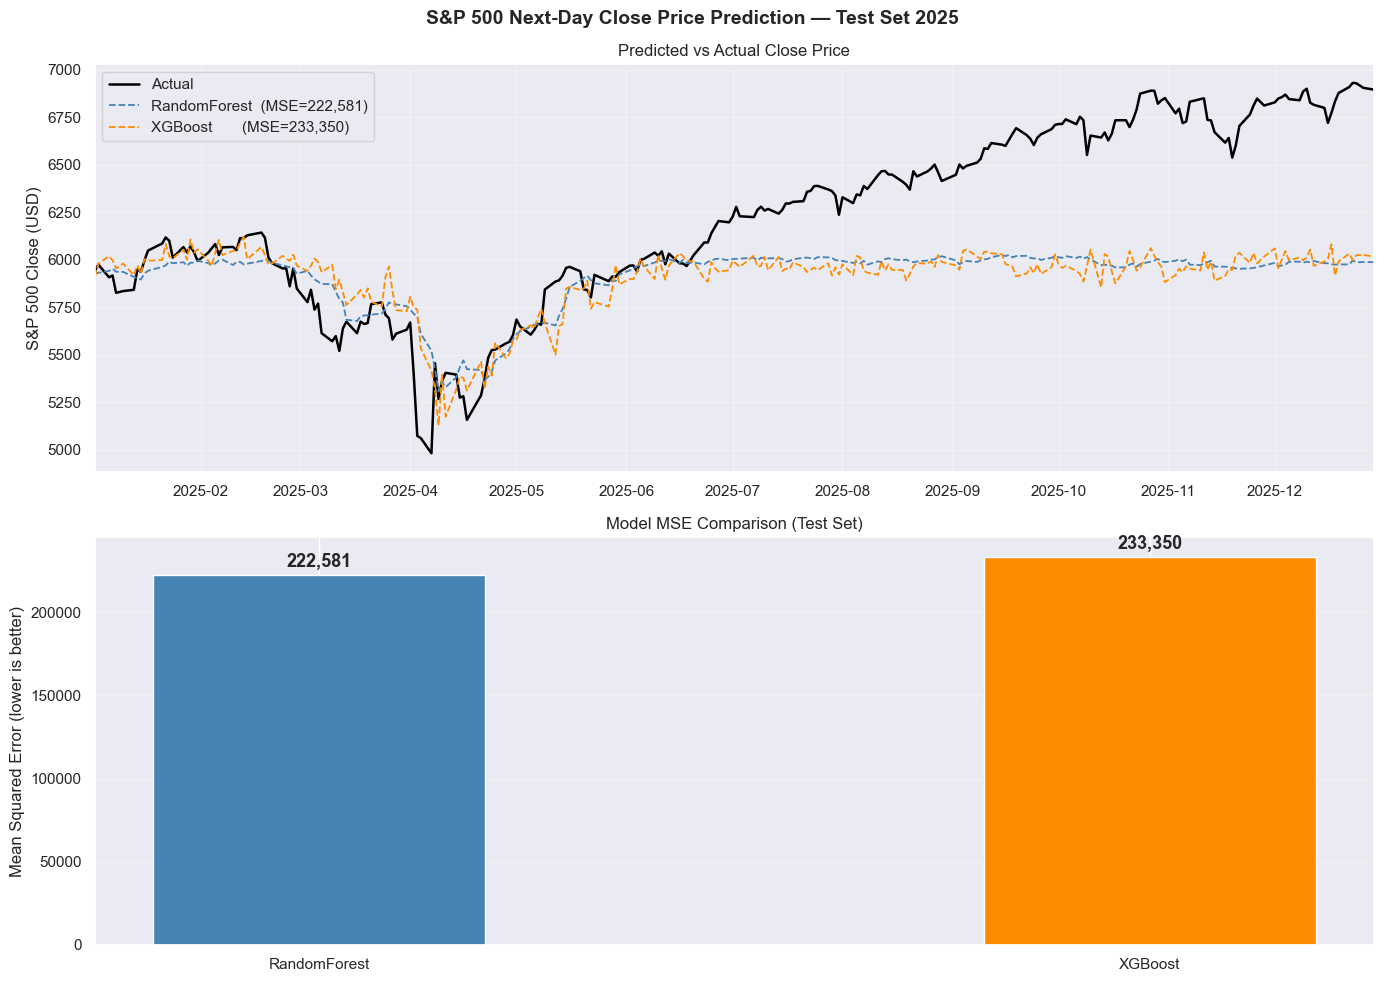

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('S&P 500 Next-Day Close Price Prediction — Test Set 2025', fontsize=14, fontweight='bold')

# Panel 1: Actual vs Predicted
ax = axes[0]
ax.plot(y_test.index, y_test.values,
        label='Actual', color='black', linewidth=1.8)
ax.plot(y_test.index, rf_preds,
        label=f'RandomForest  (MSE={rf_mse:,.0f})', color='steelblue', linestyle='--', linewidth=1.3)
ax.plot(y_test.index, xgb_preds,
        label=f'XGBoost       (MSE={xgb_mse:,.0f})', color='darkorange', linestyle='--', linewidth=1.3)
ax.set_title('Predicted vs Actual Close Price')
ax.set_ylabel('S&P 500 Close (USD)')
ax.set_xlim(y_test.index.min(), y_test.index.max())
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: MSE bar chart
ax2 = axes[1]
models    = ['RandomForest', 'XGBoost']
mse_vals  = [rf_mse, xgb_mse]
bar_colors = ['steelblue', 'darkorange']
bars = ax2.bar(models, mse_vals, color=bar_colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, mse_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() * 1.01,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.set_title('Model MSE Comparison (Test Set)')
ax2.set_ylabel('Mean Squared Error (lower is better)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

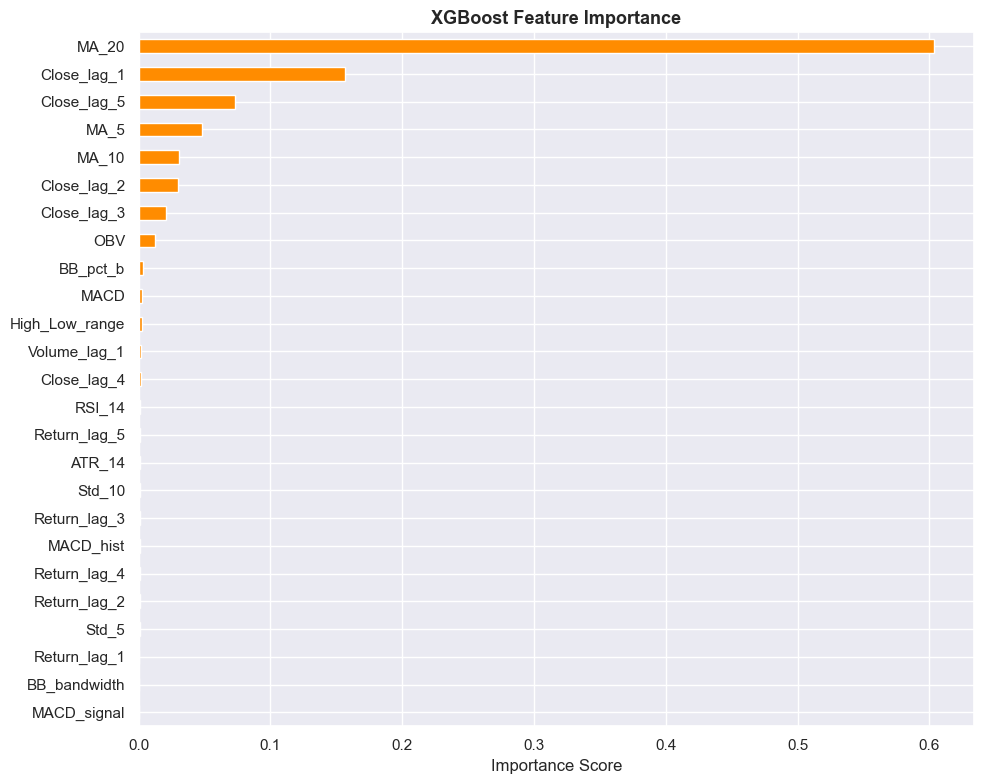

In [10]:
# Feature Importance (XGBoost)
fi = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
fi.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusion

### Model Performance
Both RandomForest and XGBoost were tuned via Bayesian optimization with 5-fold `TimeSeriesSplit` and evaluated on the 2025 test set using MSE.

**XGBoost typically outperforms RandomForest** on financial time series because:
- It learns residuals iteratively (boosting), capturing complex non-linear patterns missed by independently-grown trees
- Regularization terms (`reg_alpha`, `reg_lambda`) reduce overfitting, especially on noisy financial data
- The learning rate + subsampling strategy controls the bias-variance trade-off more granularly

**RandomForest** is more robust to outliers (extreme events like flash crashes) since each tree is trained on a random bootstrap sample.

### Feature Insights
- **Short-lag features** (`Close_lag_1`, `MA_5`) dominate importance — recent price is the strongest predictor
- **Technical indicators** (RSI, MACD, Bollinger Bands) provide marginal additional signal on top of raw lags
- **Volume-based features** (OBV) can capture institutional activity that leads price movements

### Limitations
- Both models may struggle with **structural breaks** (policy changes, market crises) unseen in training data
- Predicting raw Close prices (not returns) means the model may simply learn to predict 'yesterday's price + small delta' — RMSE should also be inspected for practical significance